# Proyecto de Clasificación

## Métodos para el Análisis de Datos I

### Introducción

En este trabajo se aborda un problema de clasificación supervisada utilizando el conjunto de datos **Breast Cancer Wisconsin**, disponible en la biblioteca `scikit-learn`.

El objetivo es construir modelos capaces de clasificar tumores como **malignos** o **benignos** a partir de distintas mediciones obtenidas mediante imágenes digitalizadas.

En esta primera parte se realizará un análisis exploratorio de los datos con el fin de comprender la estructura del conjunto, analizar la distribución de las variables y detectar posibles problemas antes del entrenamiento de los modelos.

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

plt.style.use("ggplot")

In [11]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
print(f"Número de observaciones: {X.shape[0]}")
print(f"Número de variables: {X.shape[1]}")

Número de observaciones: 569
Número de variables: 30


## Variable respuesta

La variable objetivo toma dos valores:

- 0 : Tumor maligno
- 1 : Tumor benigno

Antes de entrenar cualquier modelo resulta conveniente estudiar la distribución de las clases para detectar posibles problemas de desbalance.

In [13]:
clases = y.value_counts().sort_index()

print(clases)

target
0    212
1    357
Name: count, dtype: int64


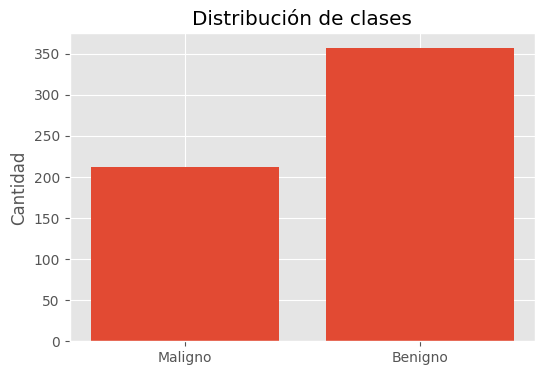

In [14]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Maligno","Benigno"],
    clases.values
)

plt.ylabel("Cantidad")

plt.title("Distribución de clases")

plt.show()


Se observa que ambas clases se encuentran relativamente balanceadas, aunque la clase correspondiente a tumores benignos posee una mayor cantidad de observaciones.

Esto permite utilizar Accuracy como una primera medida de desempeño, aunque posteriormente también se evaluarán métricas como Precision, Recall, F1-score y ROC-AUC.

In [15]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [16]:
print(X.isnull().sum().sum())

0


In [17]:
corr = X.corr()

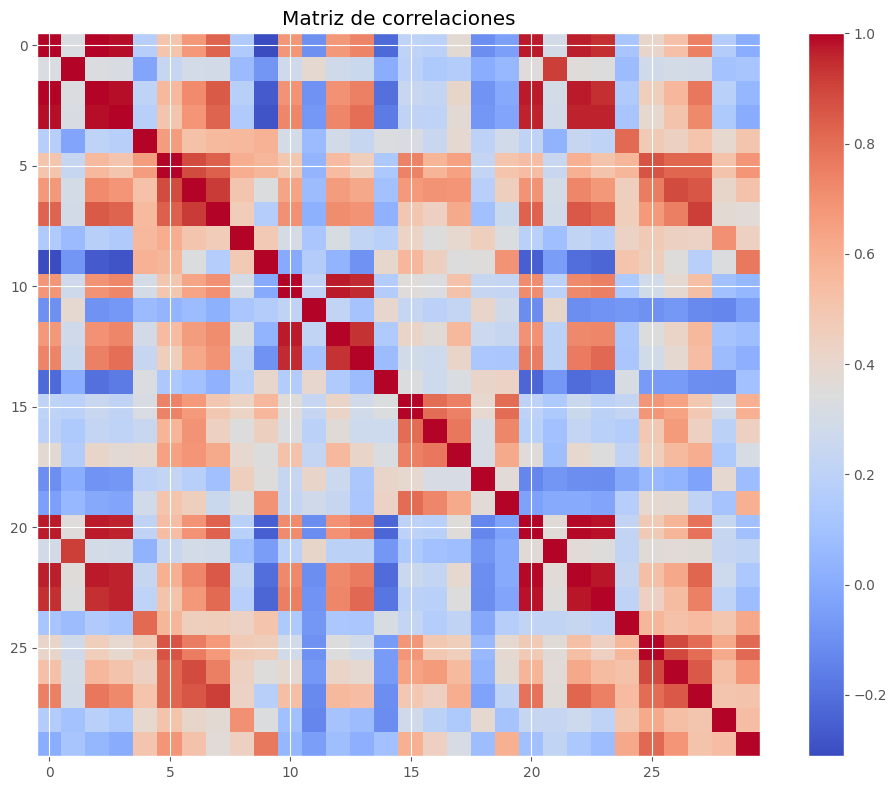

In [18]:
plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.title("Matriz de correlaciones")

plt.tight_layout()

plt.show()

### Correlaciones

La matriz de correlaciones permite observar que existen grupos de variables fuertemente correlacionadas.

Este comportamiento es esperable, ya que muchas de las características fueron obtenidas a partir de una misma imagen mediante distintos procedimientos de medición.

In [19]:
corr_target = X.corrwith(y)

corr_target.sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

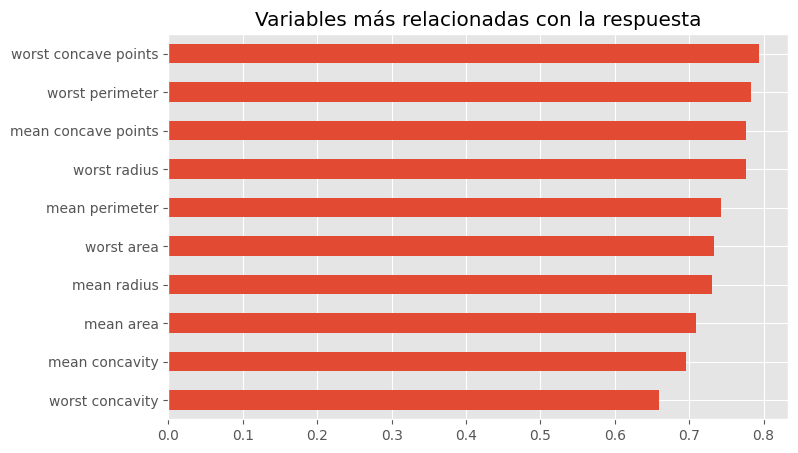

In [20]:
corr_target.abs().sort_values().tail(10).plot.barh(figsize=(8,5))

plt.title("Variables más relacionadas con la respuesta")

plt.show()

## Conclusiones del análisis exploratorio

A partir del análisis realizado pueden destacarse las siguientes observaciones:

- El conjunto de datos contiene 569 observaciones y 30 variables predictoras.
- No existen valores faltantes.
- Las clases presentan un leve desbalance, aunque no es tan extremo.
- Existen correlaciones elevadas entre varias variables.
- Algunas variables muestran una relación considerable con la variable objetivo.

En el siguiente notebook se construirán distintos modelos de clasificación para comparar su capacidad predictiva.